# Stage 3: Model Training & Evaluation

**Objective:** Split the engineered dataset into training and testing sets using stratification to preserve the minority class. Establish a baseline metric, train a Random Forest classifier optimized for class imbalance, and evaluate its performance using the $F_2$-score.

In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split


# Load processed dataset
df = pd.read_csv('../data/processed/processed_data.csv')

# Define features and target variable
features = ['Type','Air temperature [K]','Process temperature [K]','Rotational speed [rpm]','Torque [Nm]','Tool wear [min]','Temp_diff','Power','Wear_warning']

X = df[features]
y = df['Target']

# Train/Test split (80/20) with stratification to maintain the 3.4% failure rate
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set shape: {X_train.shape}")
print(f"Train minority class ratio: {y_train.mean():.4f}")
print(f"Test minority class ratio: {y_test.mean():.4f}")

Training set shape: (8000, 9)
Train minority class ratio: 0.0339
Test minority class ratio: 0.0340


## Baseline Model

Establishing a "zero-intelligence" baseline using a Dummy Classifier. This proves that high Accuracy is misleading for imbalanced datasets and sets the minimum $F_2$-score our actual model must beat.

In [11]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, fbeta_score


# Initialize and train a model that always predicts the majority class (0 - No Failure)
dummy_clf = DummyClassifier(strategy='most_frequent')
dummy_clf.fit(X_train, y_train)

y_pred_dummy = dummy_clf.predict(X_test)

print("--- Dummy Classifier Report ---")
print(classification_report(y_test, y_pred_dummy, zero_division=0))

# Calculate F2-score (beta=2 prioritizes Recall)
f2_dummy = fbeta_score(y_test, y_pred_dummy, beta=2, zero_division=0)
print(f'Baseline F2 score: {f2_dummy}')

--- Dummy Classifier Report ---
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1932
           1       0.00      0.00      0.00        68

    accuracy                           0.97      2000
   macro avg       0.48      0.50      0.49      2000
weighted avg       0.93      0.97      0.95      2000

Baseline F2 score: 0.0


## Random Forest Classifier

Training an ensemble model capable of capturing non-linear relationships. The `class_weight='balanced'` parameter is critical here to heavily penalize the model for missing actual failures (class 1).

In [12]:
from sklearn.ensemble import RandomForestClassifier


# Initialize Random Forest with balanced class weights to handle the 96:4 imbalance
rf_clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)

rf_clf.fit(X_train, y_train)

y_pred_rf = rf_clf.predict(X_test)

print("--- Random Forest Report ---")
print(classification_report(y_test, y_pred_rf))

f2_rf = fbeta_score(y_test, y_pred_rf, beta=2)
print(f'Baseline F2 score: {f2_rf:.4f}')

--- Random Forest Report ---
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.90      0.76      0.83        68

    accuracy                           0.99      2000
   macro avg       0.94      0.88      0.91      2000
weighted avg       0.99      0.99      0.99      2000

Baseline F2 score: 0.7879


## Error Analysis: Confusion Matrix

Visualizing the exact breakdown of True Positives (caught failures) vs. False Negatives (missed failures) to understand the business impact of the model.

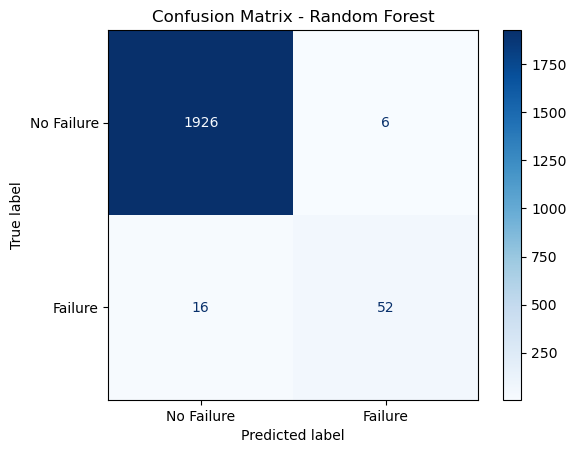

In [13]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

plt.style.use('default')
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    cmap='Blues',
    display_labels=['No Failure', 'Failure']
)

plt.title('Confusion Matrix - Random Forest')
plt.show()

## Feature Importance Interpretation

Extracting internal decision criteria from the Random Forest to validate our feature engineering efforts and determine physical causes of equipment failure.

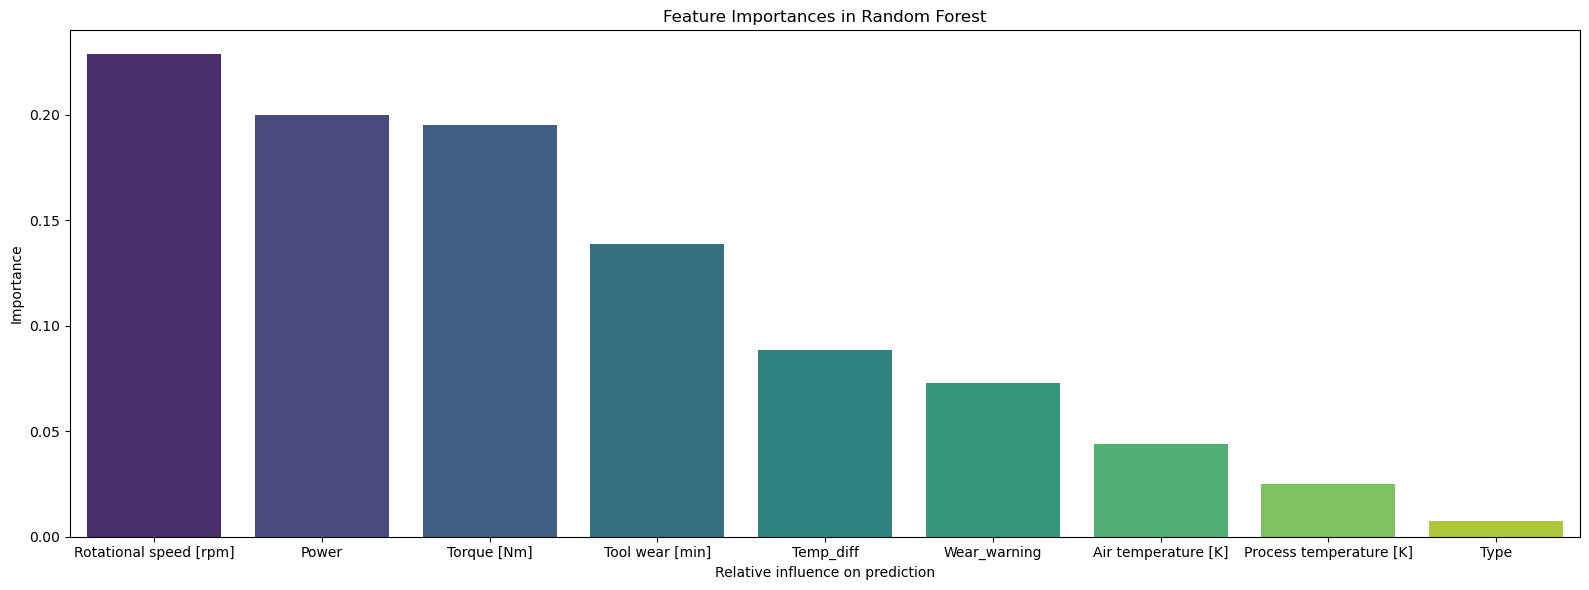

In [14]:
import pandas as pd
import seaborn as sns


# Aggregate feature importances
importances = pd.DataFrame({
    'Feature' : X_train.columns,
    'Importance' : rf_clf.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(16, 6))
sns.barplot(x='Feature', y='Importance', data=importances, hue='Feature', legend=False, palette='viridis')
plt.title('Feature Importances in Random Forest')
plt.xlabel('Relative influence on prediction')
plt.tight_layout()
plt.show()